# Bias Analysis - Study2a

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import matplotlib.colors as mcolors
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from scipy import stats
import itertools
import string

In [2]:
ageRisk = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

In [3]:
ageRisk.shape

(977, 12)

## Resolving ETFs 

In [4]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'cond', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [5]:
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

study1_etf_data = pd.read_csv('../study1/etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0, low_memory=False)
study1_fund_data = pd.read_csv('../study1/mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0, low_memory=False)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
study1_etf_data = prepare_refinitiv_dataset(study1_etf_data, cols_refinitiv)
study1_etfs = study1_etf_data['fund'].unique()

study1_fund_data = study1_fund_data.iloc[:,:-2]
study1_fund_data = prepare_refinitiv_dataset(study1_fund_data, cols_refinitiv)
study1_funds = study1_fund_data['fund'].unique()

study2b_fund_data = pd.read_csv('../study2b/data/refinitiv/funds_refinitiv_study2b.csv', index_col=0, low_memory=False)
study2b_fund_data = prepare_refinitiv_dataset(study2b_fund_data, cols_refinitiv)
study2b_funds = study2b_fund_data['fund'].unique()

study2a_addition_data = pd.read_csv('../study1/etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
study2a_addition_data = prepare_refinitiv_dataset(study2a_addition_data, cols_refinitiv)
study2a_additions = study2a_addition_data['fund'].unique()

prev_etfs = np.union1d(np.union1d(study1_etfs, study2b_funds), study2a_additions ) 
prev_funds = np.union1d(np.union1d(study1_funds, study2b_funds), study2a_additions)

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

In [6]:
new_etfs

['XBI',
 'LIT',
 'TLH',
 'SCHK',
 'GBTC',
 'REET',
 'MCHI',
 'INDA',
 'IWO',
 'ARKF',
 'IPO',
 'CIBR',
 'USMV',
 'SCHD',
 'IYR',
 'PBW',
 'USO']

In [7]:
resStr_etf = ""
os = ['MCHI', 'IXUS', 'ACWX', 'DVY', 'CIBR']
ks = ['SCHK', 'REET', 'INDA', 'ARKF', 'SCHD', 'USMV']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'XBI;LIT;TLH;SCHK.K;GBTC;REET.K;MCHI.O;INDA.K;IWO;ARKF.K;IPO;CIBR.O;USMV.K;SCHD.K;IYR;PBW;USO;'

In [8]:
new_funds

[nan, 'VTISX', 'PRBLX']

In [9]:
resStr_mutualFunds = "";
delisted = ['VTWSX', 'VDAIX']
for fund in new_funds:
    if fund in delisted:
        resStr_mutualFunds += f'{fund}.O^K19;'
    else:
        resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

'nan.O;VTISX.O;PRBLX.O;'

In [10]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

'XBI;LIT;TLH;SCHK.K;GBTC;REET.K;MCHI.O;INDA.K;IWO;ARKF.K;IPO;CIBR.O;USMV.K;SCHD.K;IYR;PBW;USO;nan.O;VTISX.O;PRBLX.O;'

In [11]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [12]:
cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector']

study2a_fund_data = pd.read_csv('./data/refinitiv/funds_refinitiv_study2a.csv', index_col=0, low_memory=False)
study2a_fund_data = prepare_refinitiv_dataset(study2a_fund_data, cols_refinitiv)
study2a_fund_data = study2a_fund_data[study2a_fund_data['fund'].isin(new_funds)]

study2a_etf_data = pd.read_csv('./data/refinitiv/etfs_refinitiv_study2a.csv', index_col=0)
study2a_etf_data = prepare_refinitiv_dataset(study2a_etf_data, cols_refinitiv)
study2a_etf_data = study2a_etf_data[study2a_etf_data['fund'].isin(new_etfs)]

etf_data = pd.concat([
    study1_etf_data, 
    study2a_fund_data,
    study2a_addition_data,
    study2a_etf_data], ignore_index=True)

fund_data = pd.concat([
    study1_etf_data, 
    study1_fund_data, 
    study2a_addition_data, 
    study2a_fund_data,
    study2a_etf_data,
    study2b_fund_data], ignore_index=True)

In [13]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df, select_cols):
    df = df.merge(etf_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors)
    #return df
    return resolve_layer2(df, select_cols)

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('../study1/benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))


In [14]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [15]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    cond = df['cond'].unique()
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'iteration', 'cond', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'cond', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [16]:
mpl.rcParams['font.size'] = 14  # Change the size to your preference
mpl.rcParams['font.sans-serif'] = 'Arial'

In [17]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        d = group_values.mean() - benchmark
        print(f'group: {group_name} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 2)} d: {round(d, 2)}')

def show_ttest_ind(raw, column, groups):
    unique_groups = raw[groups].unique()
    if len(unique_groups) != 2:
        print('Error occured calculating the t-test between the groups.')
        return

    group1, group2 = unique_groups
    data1 = raw[raw[groups] == group1][column].dropna()
    data2 = raw[raw[groups] == group2][column].dropna()
    print(stats.ttest_ind(data1, data2))
    t_stat, p_value = stats.ttest_ind(data1, data2)
    print(f'group1: {group1} and group2: {group2} got t: {round(t_stat,2)}, p_value: {round(p_value,4)}, df: {len(data1) + len(data2) - 2}')
    

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    if group2:
        show_anova(raw, column, group1, group2, onlyGroup)
    else:
        show_ttest_ind(raw, column, group1)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2, onlyGroup)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['cond', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

ageRisk_resolved['cond'] = ageRisk_resolved['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})
ageRisk['cond'] = ageRisk['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})


## Geographic cluster risk

In [18]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out due to wrong labeling
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)
(1304007, 35)


TtestResult(statistic=2.939116700854856, pvalue=0.003727993926274269, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 2.94, p_value: 0.0037, df: 178
group: ('Control prompt',) got t: 38.39 p_value: 0.0 dfs: 89 benchmark: 58.96 d: 35.98
group: ('Debiased prompt',) got t: 25.51 p_value: 0.0 dfs: 89 benchmark: 58.96 d: 31.43
means:
cond
Control prompt     94.94
Debiased prompt    90.39
Name: weight, dtype: float64
stds:
cond
Control prompt      8.89
Debiased prompt    11.69
Name: weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: weight, dtype: int64


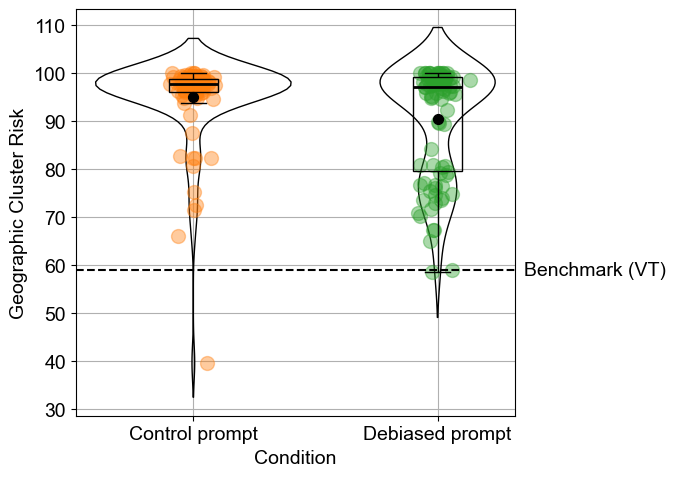

In [19]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond',
    'study2a_geoRisk'
)

In [20]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'cond', 'risk-taking')

                sum_sq     df         F    PR(>F)
label      2315.878104    5.0  4.525155  0.000665
Residual  17809.898497  174.0       NaN       NaN
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                     group2           meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)   0.0608    1.0  -7.4669  7.5886  False
  (Control prompt, averse)  (Control prompt, seeking)  -6.1432 0.1795  -13.671  1.3845  False
  (Control prompt, averse)  (Debiased prompt, averse)  -10.077 0.0022 -17.6048 -2.5493   True
  (Control prompt, averse) (Debiased prompt, neutral)  -5.9139 0.2147 -13.4417  1.6139  False
  (Control prompt, averse) (Debiased prompt, seeking)  -3.7407 0.7075 -11.2684  3.7871  False
 (Control prompt, neutral)  (Control prompt, seeking)   -6.204 0.1709 -13.7318  1.3237  False
 (Co

In [21]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'cond', 'age')

                sum_sq     df         F    PR(>F)
label      1701.511513    5.0  3.213838  0.008423
Residual  18424.265088  174.0       NaN       NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)  -2.8453 0.8923 -10.5018  4.8112  False
 (Control prompt, 15)  (Control prompt, 50)   0.1127    1.0  -7.5438  7.7692  False
 (Control prompt, 15) (Debiased prompt, 15)   -2.412 0.9441 -10.0685  5.2445  False
 (Control prompt, 15) (Debiased prompt, 30)  -8.7323 0.0153 -16.3888 -1.0758   True
 (Control prompt, 15) (Debiased prompt, 50)  -5.2375 0.3631  -12.894   2.419  False
 (Control prompt, 30)  (Control prompt, 50)    2.958 0.8753  -4.6985 10.6145  False
 (Control prompt, 30) (Debiased prompt, 15)   0.4333    1.0  -7.2232  8.0898  False
 (Control 

## Sector cluster risk

In [22]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before
sec = calculate_concentration(sec, group_cols)

(9621, 15)
(1248146, 35)


TtestResult(statistic=2.105321106660373, pvalue=0.03666649794700869, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 2.11, p_value: 0.0367, df: 178
group: ('Control prompt',) got t: 11.91 p_value: 0.0 dfs: 89 benchmark: 0.15 d: 0.17
group: ('Debiased prompt',) got t: 8.36 p_value: 0.0 dfs: 89 benchmark: 0.15 d: 0.12
means:
cond
Control prompt     0.32
Debiased prompt    0.28
Name: concentration, dtype: float64
stds:
cond
Control prompt     0.13
Debiased prompt    0.14
Name: concentration, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: concentration, dtype: int64


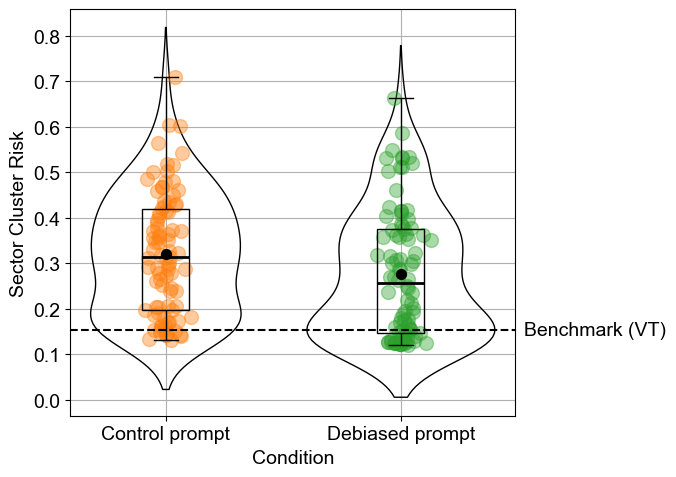

In [23]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond',
    'study2a_sectorRisk'
)

In [24]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'cond', 'risk-taking')

            sum_sq     df          F        PR(>F)
label     1.656507    5.0  32.420312  2.835805e-23
Residual  1.778096  174.0        NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                     group2           meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)   0.1265    0.0  0.0513  0.2018   True
  (Control prompt, averse)  (Control prompt, seeking)   0.1958    0.0  0.1206   0.271   True
  (Control prompt, averse)  (Debiased prompt, averse)  -0.0602 0.1969 -0.1354   0.015  False
  (Control prompt, averse) (Debiased prompt, neutral)   0.0581  0.232 -0.0172  0.1333  False
  (Control prompt, averse) (Debiased prompt, seeking)   0.1953    0.0  0.1201  0.2706   True
 (Control prompt, neutral)  (Control prompt, seeking)   0.0693   0.09 -0.0059  0.1445  False
 (Control 

In [25]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'cond', 'age')

            sum_sq     df         F    PR(>F)
label     0.310879    5.0  3.463362  0.005216
Residual  3.123724  174.0       NaN       NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)  -0.1109 0.0197 -0.2106 -0.0112   True
 (Control prompt, 15)  (Control prompt, 50)  -0.0864 0.1308 -0.1861  0.0133  False
 (Control prompt, 15) (Debiased prompt, 15)  -0.0858 0.1358 -0.1855  0.0139  False
 (Control prompt, 15) (Debiased prompt, 30)  -0.1188 0.0095 -0.2185 -0.0191   True
 (Control prompt, 15) (Debiased prompt, 50)  -0.1218 0.0072 -0.2215 -0.0221   True
 (Control prompt, 30)  (Control prompt, 50)   0.0245 0.9808 -0.0752  0.1242  False
 (Control prompt, 30) (Debiased prompt, 15)   0.0251 0.9787 -0.0746  0.1248  False
 (Control prompt, 30) (Debiased 

## Concentration Map

In [60]:
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)} and dif: {round(group_values.mean()-benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(1232105, 35)
             sum_sq      df           F  PR(>F)
label     21.514462    13.0  213.676974     0.0
Residual  19.409327  2506.0         NaN     NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0116 0.9938 -0.0196  0.0427  False
           Academic & Educational Services                     Communication Services   0.0271 0.1686  -0.004  0.0583  False
           Academic & Educational Services                          Consumer Cyclical   0.2384    0.0  0.2073  0.2696   True
           Academic & Educational Services                     Consumer Non-Cyclicals   0.04

In [65]:
def show_condition_matched_ttest(raw, column, cond_col):
    conds = raw[cond_col].unique()
    cond_1, cond_2 = conds[:2]
    elems = raw[column].unique()
    for elem in elems:
        data_1 = raw[(raw[cond_col] == cond_1) & (raw[column] == elem)]['weight']
        data_2 = raw[(raw[cond_col] == cond_2) & (raw[column] == elem)]['weight']
        t_stat, p_value = stats.ttest_ind(data_1, data_2)
        print(f'for {elem}: t={round(t_stat,2)}, p-value={round(p_value, 4)}, dif={round(data_2.mean() - data_1.mean(), 2)}')

show_condition_matched_ttest(sec_ov, 'sector', 'cond')

for Technology: t=1.71, p-value=0.0892, dif=-0.05
for Consumer Cyclical: t=0.52, p-value=0.6048, dif=-0.02
for Consumer Non-Cyclicals: t=0.54, p-value=0.5916, dif=-0.01
for Healthcare: t=-0.4, p-value=0.6894, dif=0.0
for Financials: t=-2.08, p-value=0.039, dif=0.01
for Energy: t=-1.97, p-value=0.0499, dif=0.01
for Basic Materials: t=-3.84, p-value=0.0002, dif=0.01
for Utilities: t=-1.88, p-value=0.0613, dif=0.01
for Industrials: t=-2.03, p-value=0.044, dif=0.01
for Real Estate: t=-1.07, p-value=0.2848, dif=0.01
for Government Activity: t=0.39, p-value=0.6938, dif=-0.01
for Academic & Educational Services: t=-1.54, p-value=0.1259, dif=0.0
for Institutions, Associations & Organizations: t=-0.44, p-value=0.6573, dif=0.0
for Communication Services: t=-0.62, p-value=0.5378, dif=0.01


(9485, 15)


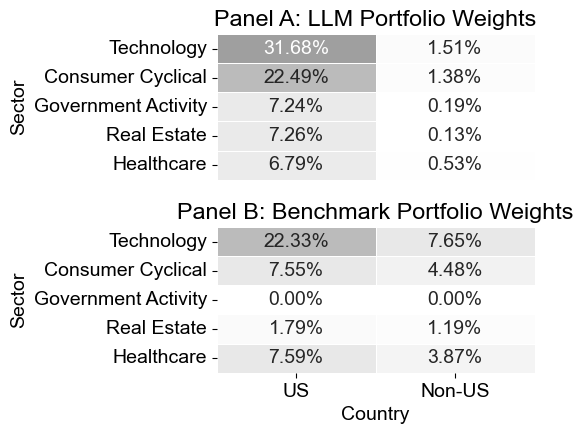

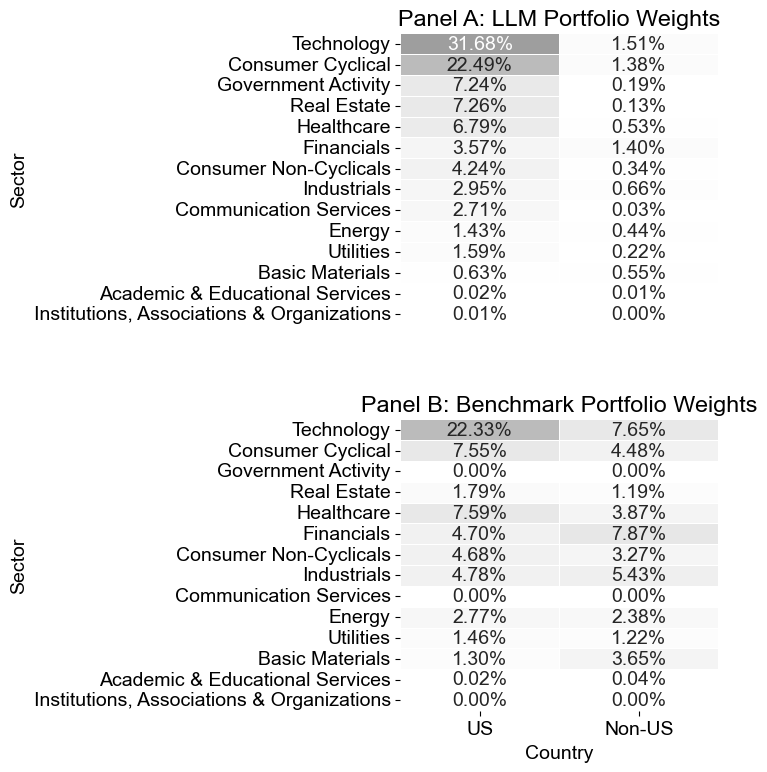

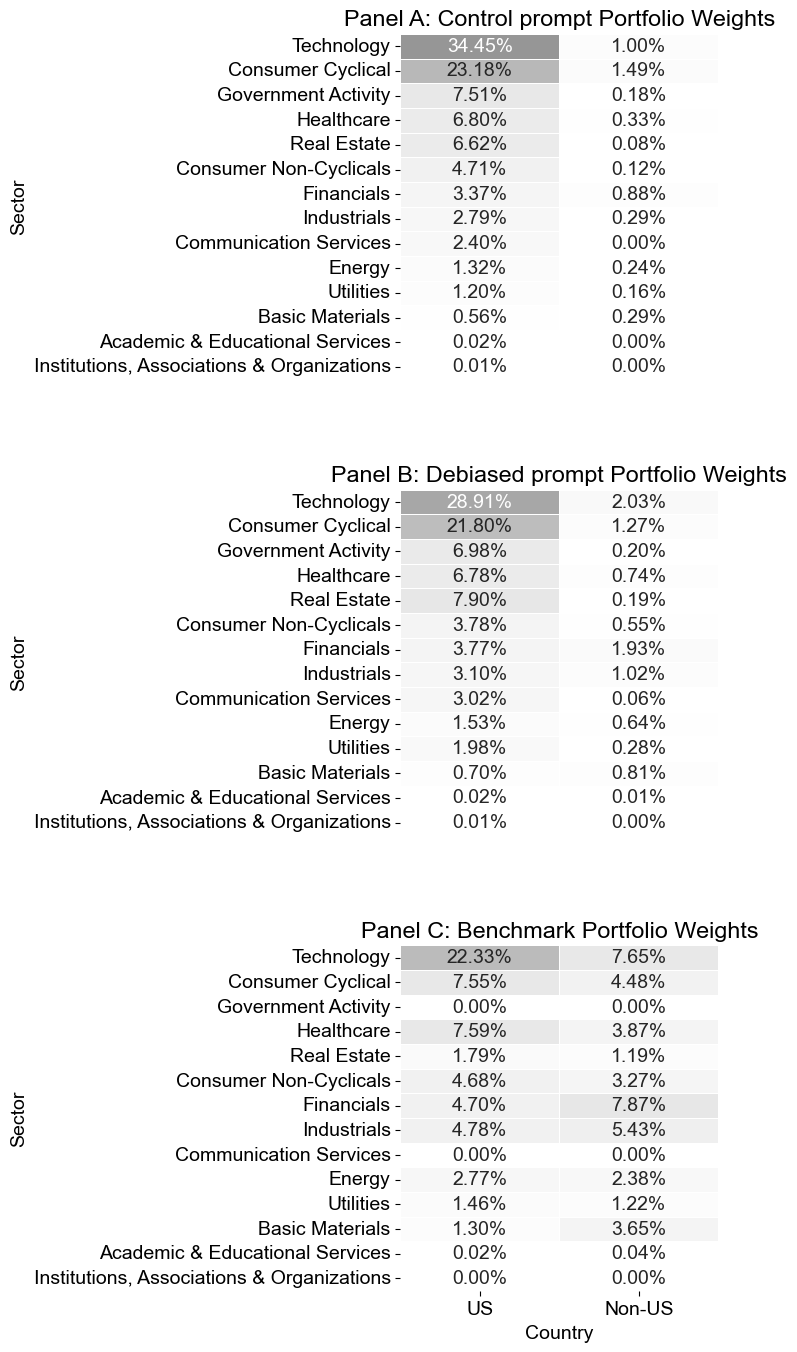

In [29]:
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

import numpy as np

def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    g.set_axis_labels("Country", "Sector")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study2a_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study2a_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study2a_concentration_map_details', False, 4, 14)

(9485, 15)


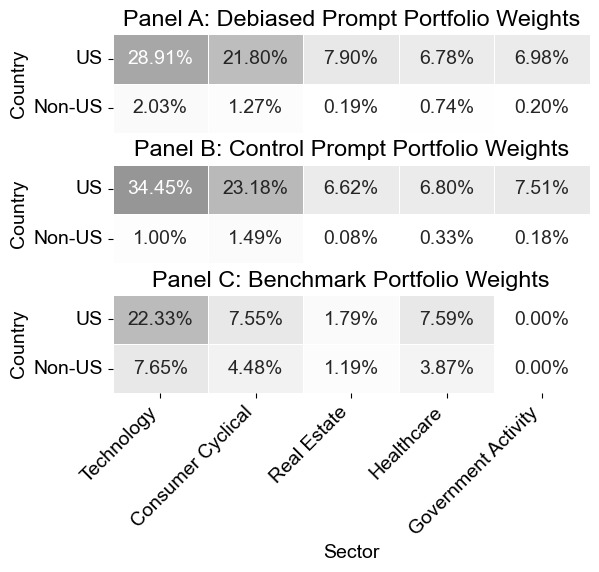

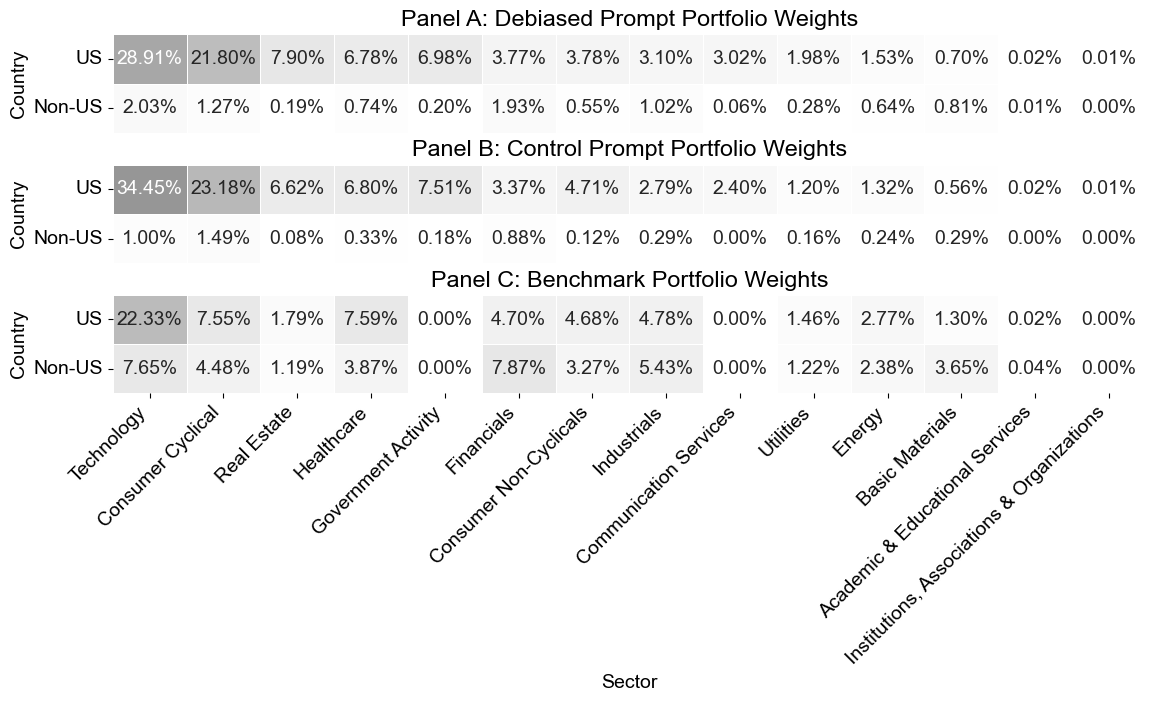

In [30]:
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()
    combined_df = combined_df.sort_values(by='type', ascending=False)
    replacements = {'Control prompt': 'Control Prompt', 'Debiased prompt': 'Debiased Prompt'}
    combined_df['type'] = combined_df['type'].replace(replacements)

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    g.set_axis_labels("Sector", "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study2a_overview_concentration_map_horizontal', True, 6, 4)
show_faceted_heatmap(combined_details, 'study2a_details_concentration_map_horizontal', False, 13, 4)

## Active investment allocation risk

In [31]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]

ter_data_study2b = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study2a = pd.read_csv('./data/refinitiv/ter_study2a.csv', index_col=0)
ter_data_study2a = ter_data_study2a.iloc[1:].reset_index()
ter_data_study2a.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b, ter_data_study2a], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [32]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

TtestResult(statistic=2.044187705050542, pvalue=0.04240802370010202, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 2.04, p_value: 0.0424, df: 178
group: ('Control prompt',) got t: 18.24 p_value: 0.0 dfs: 89 benchmark: 0 d: 59.57
group: ('Debiased prompt',) got t: 11.66 p_value: 0.0 dfs: 89 benchmark: 0 d: 48.72
means:
cond
Control prompt     59.57
Debiased prompt    48.72
Name: management_weight, dtype: float64
stds:
cond
Control prompt     30.99
Debiased prompt    39.64
Name: management_weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: management_weight, dtype: int64


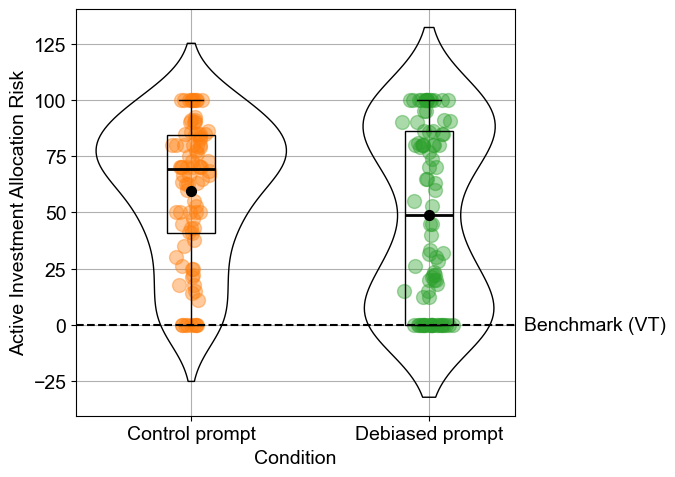

In [33]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond',
    'study2a_activeRisk'
)

In [34]:
unused = print_stats(management_data, 'management_weight', 0, 'cond', 'risk-taking')

                 sum_sq     df          F        PR(>F)
label     137084.815552    5.0  51.015598  2.281960e-32
Residual   93511.626393  174.0        NaN           NaN
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
          group1                     group2           meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)  33.8268    0.0  16.5777   51.076   True
  (Control prompt, averse)  (Control prompt, seeking)  56.6984    0.0  39.4493  73.9476   True
  (Control prompt, averse)  (Debiased prompt, averse) -17.2982 0.0489 -34.5474  -0.0491   True
  (Control prompt, averse) (Debiased prompt, neutral)  18.2458 0.0314   0.9967   35.495   True
  (Control prompt, averse) (Debiased prompt, seeking)   57.053    0.0  39.8038  74.3021   True
 (Control prompt, neutral)  (Control prompt, seeking)  22.8716 0.0025   

In [35]:
unused = print_stats(management_data, 'management_weight', 0, 'cond', 'age')

                 sum_sq     df         F    PR(>F)
label      21212.090789    5.0  3.525482  0.004627
Residual  209384.351157  174.0       NaN       NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30) -18.6346 0.3024 -44.4457  7.1765  False
 (Control prompt, 15)  (Control prompt, 50) -13.0394 0.6927 -38.8506 12.7717  False
 (Control prompt, 15) (Debiased prompt, 15)  -6.3941 0.9801 -32.2052 19.4171  False
 (Control prompt, 15) (Debiased prompt, 30) -26.6493 0.0386 -52.4605 -0.8382   True
 (Control prompt, 15) (Debiased prompt, 50) -31.1553 0.0082 -56.9665 -5.3442   True
 (Control prompt, 30)  (Control prompt, 50)   5.5952 0.9891 -20.2159 31.4063  False
 (Control prompt, 30) (Debiased prompt, 15)  12.2405 0.7469 -13.5706 38.0517  False
 (Contr

## Total Expense Risk

In [36]:
fund_identifiers = ter_data['fund'].unique()
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

TtestResult(statistic=0.46216259137610716, pvalue=0.6445886563396708, df=161.0)
group1: Control prompt and group2: Debiased prompt got t: 0.46, p_value: 0.6446, df: 161
group: ('Control prompt',) got t: 5.34 p_value: 0.0 dfs: 85 benchmark: 0.07 d: 0.12
group: ('Debiased prompt',) got t: 4.63 p_value: 0.0 dfs: 76 benchmark: 0.07 d: 0.11
means:
cond
Control prompt     0.19
Debiased prompt    0.18
Name: ter_weight, dtype: float64
stds:
cond
Control prompt     0.21
Debiased prompt    0.20
Name: ter_weight, dtype: float64
cond
Control prompt     86
Debiased prompt    77
Name: ter_weight, dtype: int64


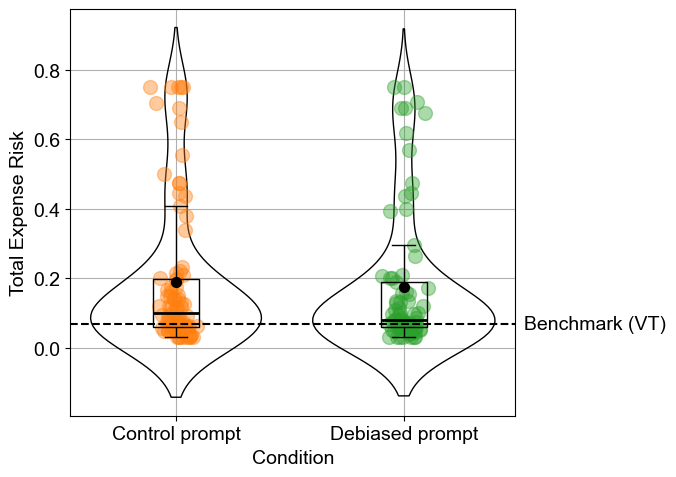

In [37]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond',
    'study2a_terRisk'
)

In [38]:
# Control for different N (portfolios being excluded due to no investment in ETFs or mutual funds
ter_control = grouped_ter[grouped_ter['cond'] == 'Control prompt']['ter_weight']
ter_debiased = grouped_ter[grouped_ter['cond'] == 'Debiased prompt']['ter_weight']

stat, p = stats.mannwhitneyu(ter_control, ter_debiased)
print(f'control-debiased: {stat}, {p}')

# Perform one-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_control - ter_benchmark)
print(f'control-benchmark: {stat_bench}, {p_bench}')

stat_debiased_bench, p_debiased_bench = stats.wilcoxon(ter_debiased - ter_benchmark)
print(f'debiased-benchmark: {stat_debiased_bench}, {p_debiased_bench}')

# Perform Chi-Square test
count_control = [90-ter_control.size, ter_control.size]
count_debiased = [90-ter_debiased.size, ter_debiased.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_control, count_debiased])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

control-debiased: 3502.5, 0.5254020565532507
control-benchmark: 742.0, 1.1741970996749983e-06
debiased-benchmark: 747.0, 0.00020943346797558377
chi-square: 4.1573439191627575, 0.04145436160354038, df:1


In [39]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'cond', 'risk-taking')

            sum_sq     df          F        PR(>F)
label     3.685769    5.0  37.029394  6.001579e-25
Residual  3.125440  157.0        NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                     group2           meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)   0.0252 0.9825 -0.0799  0.1304  False
  (Control prompt, averse)  (Control prompt, seeking)    0.355    0.0  0.2459  0.4641   True
  (Control prompt, averse)  (Debiased prompt, averse)  -0.0039    1.0  -0.109  0.1012  False
  (Control prompt, averse) (Debiased prompt, neutral)   0.0316 0.9619 -0.0786  0.1419  False
  (Control prompt, averse) (Debiased prompt, seeking)   0.3236    0.0  0.2094  0.4379   True
 (Control prompt, neutral)  (Control prompt, seeking)   0.3297    0.0  0.2207  0.4388   True
 (Control 

In [40]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'cond', 'age')

            sum_sq     df         F    PR(>F)
label     0.034485    5.0  0.159787  0.976746
Residual  6.776723  157.0       NaN       NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)   -0.031 0.9935 -0.1913 0.1293  False
 (Control prompt, 15)  (Control prompt, 50)  -0.0162 0.9997 -0.1752 0.1428  False
 (Control prompt, 15) (Debiased prompt, 15)  -0.0185 0.9996 -0.1886 0.1516  False
 (Control prompt, 15) (Debiased prompt, 30)   -0.025 0.9978 -0.1881 0.1382  False
 (Control prompt, 15) (Debiased prompt, 50)  -0.0476  0.959 -0.2108 0.1155  False
 (Control prompt, 30)  (Control prompt, 50)   0.0148 0.9998 -0.1413 0.1709  False
 (Control prompt, 30) (Debiased prompt, 15)   0.0124 0.9999 -0.1549 0.1798  False
 (Control prompt, 30) (Debiased prompt, 30

## Trend chasing risk

In [41]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_prepared = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [42]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'

# Open and read the JSON file
with open(json_file_path, 'r') as json_file:
    # Load the JSON data into a dictionary
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
most_traded = []
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    most_traded.append(symbol)
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [43]:
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['cond'] == co]['amount_to_invest']
        top_total = cond[cond['cond'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['cond'] == co]
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3 = top3[top3['ticker_symbol'].isin(most_traded)]
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict

conds = ageRisk['cond'].unique()
ageRisk_cond = ageRisk.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['cond','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(conds, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(conds, top_data)

Control prompt top: % of equities: 1.0000000000000002 and % of total 0.4120148856990962
Control prompt top 3: % of equities: 0.6012903225806452 and % of total 0.2477405635300372
              cond ticker_symbol  amount_to_invest  pct_of_equities  \
0   Control prompt          AAPL           92000.0         0.237419   
24  Control prompt          TSLA           78000.0         0.201290   
3   Control prompt          AMZN           63000.0         0.162581   

    pct_of_total  
0       0.097820  
24      0.082935  
3       0.066986  

Debiased prompt top: % of equities: 0.9999999999999999 and % of total 0.3675074586384595
Debiased prompt top 3: % of equities: 0.6523985239852399 and % of total 0.23976132356929752
               cond ticker_symbol  amount_to_invest  pct_of_equities  \
26  Debiased prompt          AAPL           93500.0         0.276015   
60  Debiased prompt          TSLA           68000.0         0.200738   
30  Debiased prompt          AMZN           59500.0         0.1

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_42134/3554050832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_42134/3554050832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_42134/3554

In [44]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk-taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [45]:
def calcTopMeans(df, top_dict):
    top_df = None

    for cond, top_assets in top_dict.items():
        filtered_df = df[(df['cond'] == cond) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['cond', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('cond')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

TtestResult(statistic=0.2588575108693222, pvalue=0.796044281419405, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 0.26, p_value: 0.796, df: 178
group: ('Control prompt',) got t: 7.34 p_value: 0.0 dfs: 89 benchmark: 9.0 d: 15.5
group: ('Debiased prompt',) got t: 5.72 p_value: 0.0 dfs: 89 benchmark: 9.0 d: 14.64
means:
cond
Control prompt     24.50
Debiased prompt    23.64
Name: weight, dtype: float64
stds:
cond
Control prompt     20.03
Debiased prompt    24.26
Name: weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: weight, dtype: int64


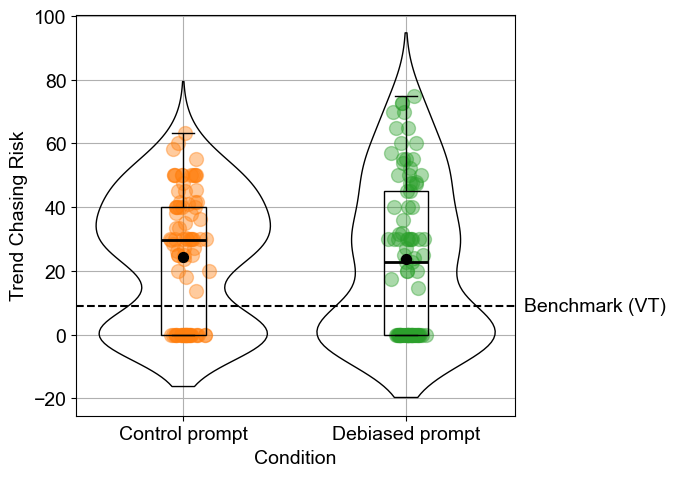

In [46]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond',
    'study2a_trendRisk'
)

In [47]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'cond', 'risk-taking')

                sum_sq     df          F        PR(>F)
label     42171.484809    5.0  31.924673  5.335902e-23
Residual  45969.700757  174.0        NaN           NaN
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
          group1                     group2           meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)  30.0311    0.0  17.9371  42.1251   True
  (Control prompt, averse)  (Control prompt, seeking)  26.0384    0.0  13.9444  38.1324   True
  (Control prompt, averse)  (Debiased prompt, averse)  -5.3203 0.8021 -17.4143   6.7737  False
  (Control prompt, averse) (Debiased prompt, neutral)   23.547    0.0   11.453   35.641   True
  (Control prompt, averse) (Debiased prompt, seeking)  35.2672    0.0  23.1732  47.3612   True
 (Control prompt, neutral)  (Control prompt, seeking)  -3.9927 0.9323 -16.0

In [48]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'cond', 'age')

                sum_sq     df         F    PR(>F)
label      4043.900712    5.0  1.673392  0.143395
Residual  84097.284854  174.0       NaN       NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)  -8.4858  0.668 -24.8437   7.872  False
 (Control prompt, 15)  (Control prompt, 50)  -6.0085  0.897 -22.3664 10.3493  False
 (Control prompt, 15) (Debiased prompt, 15)     1.87 0.9995 -14.4879 18.2278  False
 (Control prompt, 15) (Debiased prompt, 30)  -7.2475 0.7973 -23.6053  9.1103  False
 (Control prompt, 15) (Debiased prompt, 50) -11.6924 0.3134 -28.0503  4.6654  False
 (Control prompt, 30)  (Control prompt, 50)   2.4773  0.998 -13.8805 18.8351  False
 (Control prompt, 30) (Debiased prompt, 15)  10.3558 0.4529   -6.002 26.7137  False
 (Control 

## MANOVA

In [49]:
geo_us.rename(columns={'weight': 'us_weight'}, inplace=True)
trends_data.rename(columns={'weight': 'trends_weight'}, inplace=True)
print(geo_us.shape)
print(sec.shape)
print(management_data.shape)
print(grouped_ter.shape)
print(trends_data.shape)

(180, 9)
(180, 7)
(180, 10)
(163, 6)
(180, 6)


In [50]:
df_metrics = geo_us.merge(
    sec[['cond', 'age', 'risk-taking', 'iteration', 'concentration']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    management_data[['cond', 'age', 'risk-taking', 'iteration', 'management_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_ter[['cond', 'age', 'risk-taking', 'iteration', 'ter_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    trends_data[['cond', 'age', 'risk-taking', 'iteration', 'trends_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.dropna()
print(df_metrics.shape)

(163, 13)


In [52]:
df_metrics.rename(columns={'risk-taking': 'risk_taking'}, inplace=True)

In [53]:
from statsmodels.multivariate.manova import MANOVA
manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ cond', data = df_metrics)
print(manova.mv_test())

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ cond + risk_taking + age', data = df_metrics)
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0172 5.0000 157.0000 1796.5027 0.0000
         Pillai's trace  0.9828 5.0000 157.0000 1796.5027 0.0000
 Hotelling-Lawley trace 57.2135 5.0000 157.0000 1796.5027 0.0000
    Roy's greatest root 57.2135 5.0000 157.0000 1796.5027 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
             cond          Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.8498 5.0000 157.0000  5.5490 0.0001
            Pillai's trace 0.1502 5.0000 157.

In [55]:
group_levels = df_metrics['cond'].unique()

# Run MANOVA separately for each level of "cond"
for level in group_levels:
    subset = df_metrics[df_metrics['cond'] == level]  # Subset data for a specific group level
    
    print(f"\nMANOVA for cond: {level}")
    manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ risk_taking + age', data=subset)
    print(manova.mv_test())


MANOVA for cond: Control prompt
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0370 5.0000 78.0000 406.0426 0.0000
         Pillai's trace  0.9630 5.0000 78.0000 406.0426 0.0000
 Hotelling-Lawley trace 26.0284 5.0000 78.0000 406.0426 0.0000
    Roy's greatest root 26.0284 5.0000 78.0000 406.0426 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
      risk_taking       Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1604 10.0000 156.0000 23.3515 0.0000
         Pillai's trace 1.1181 10.0000 15